## A PyTorch workflow

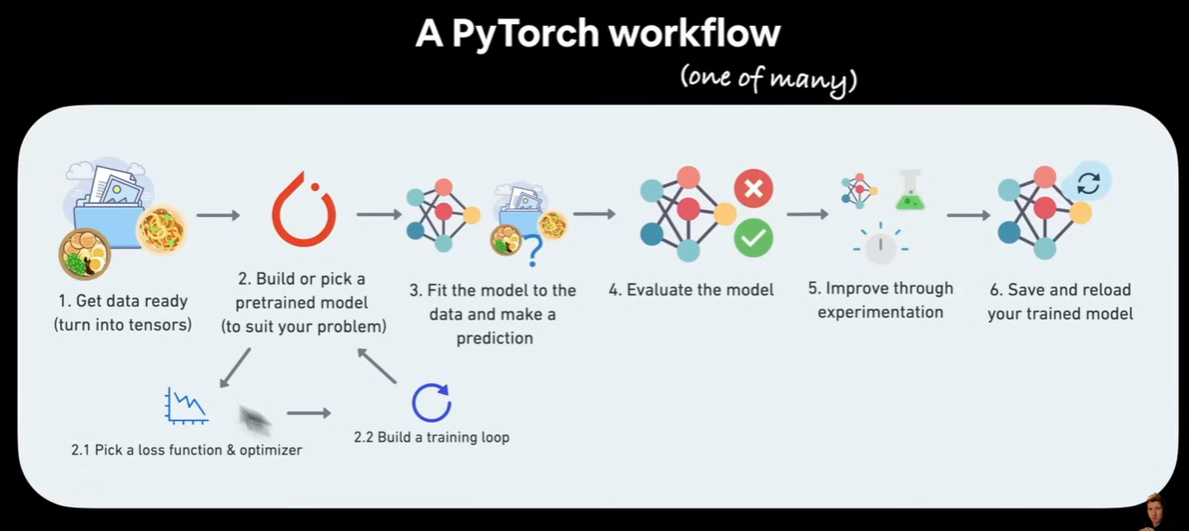

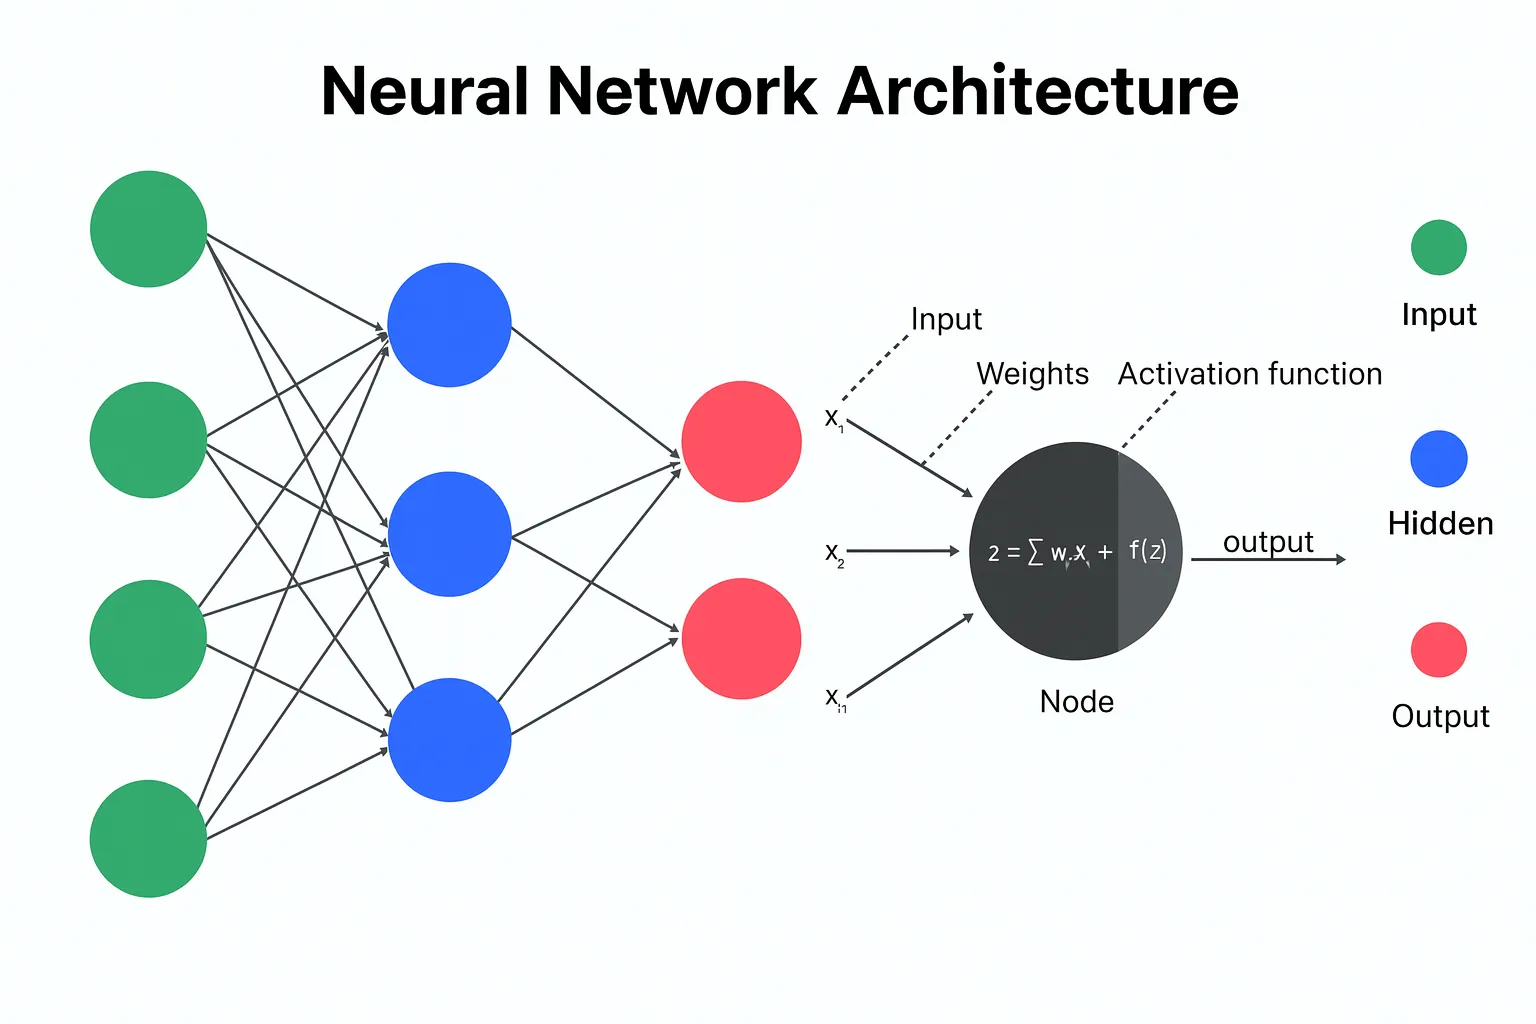

In [ ]:
# what_were_covering = {1: "data (prepare and load)",
#     2: "build model",
#     3: "fitting the model to data (training)",
#     4: "making predictions and evaluating a model (inference)",
#     5: "saving and loading a model",
#     6: "putting it all together"
# }

In [ ]:
import torch
from torch import nn # nn contain all of PyTorch's building blocks for Neural Networks
import matplotlib.pyplot as plt

torch.__version__

'2.9.0+cu126'

## 1. Data (preparing and loading)

Data can be almost anything in ML.
* Excel spreadsheet
* Image of any kind
* Videos
* Audios
* DNA patterns
* Text

Machine Learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representations.

To showcase this, let's create some *known* data using the linear regression formula.

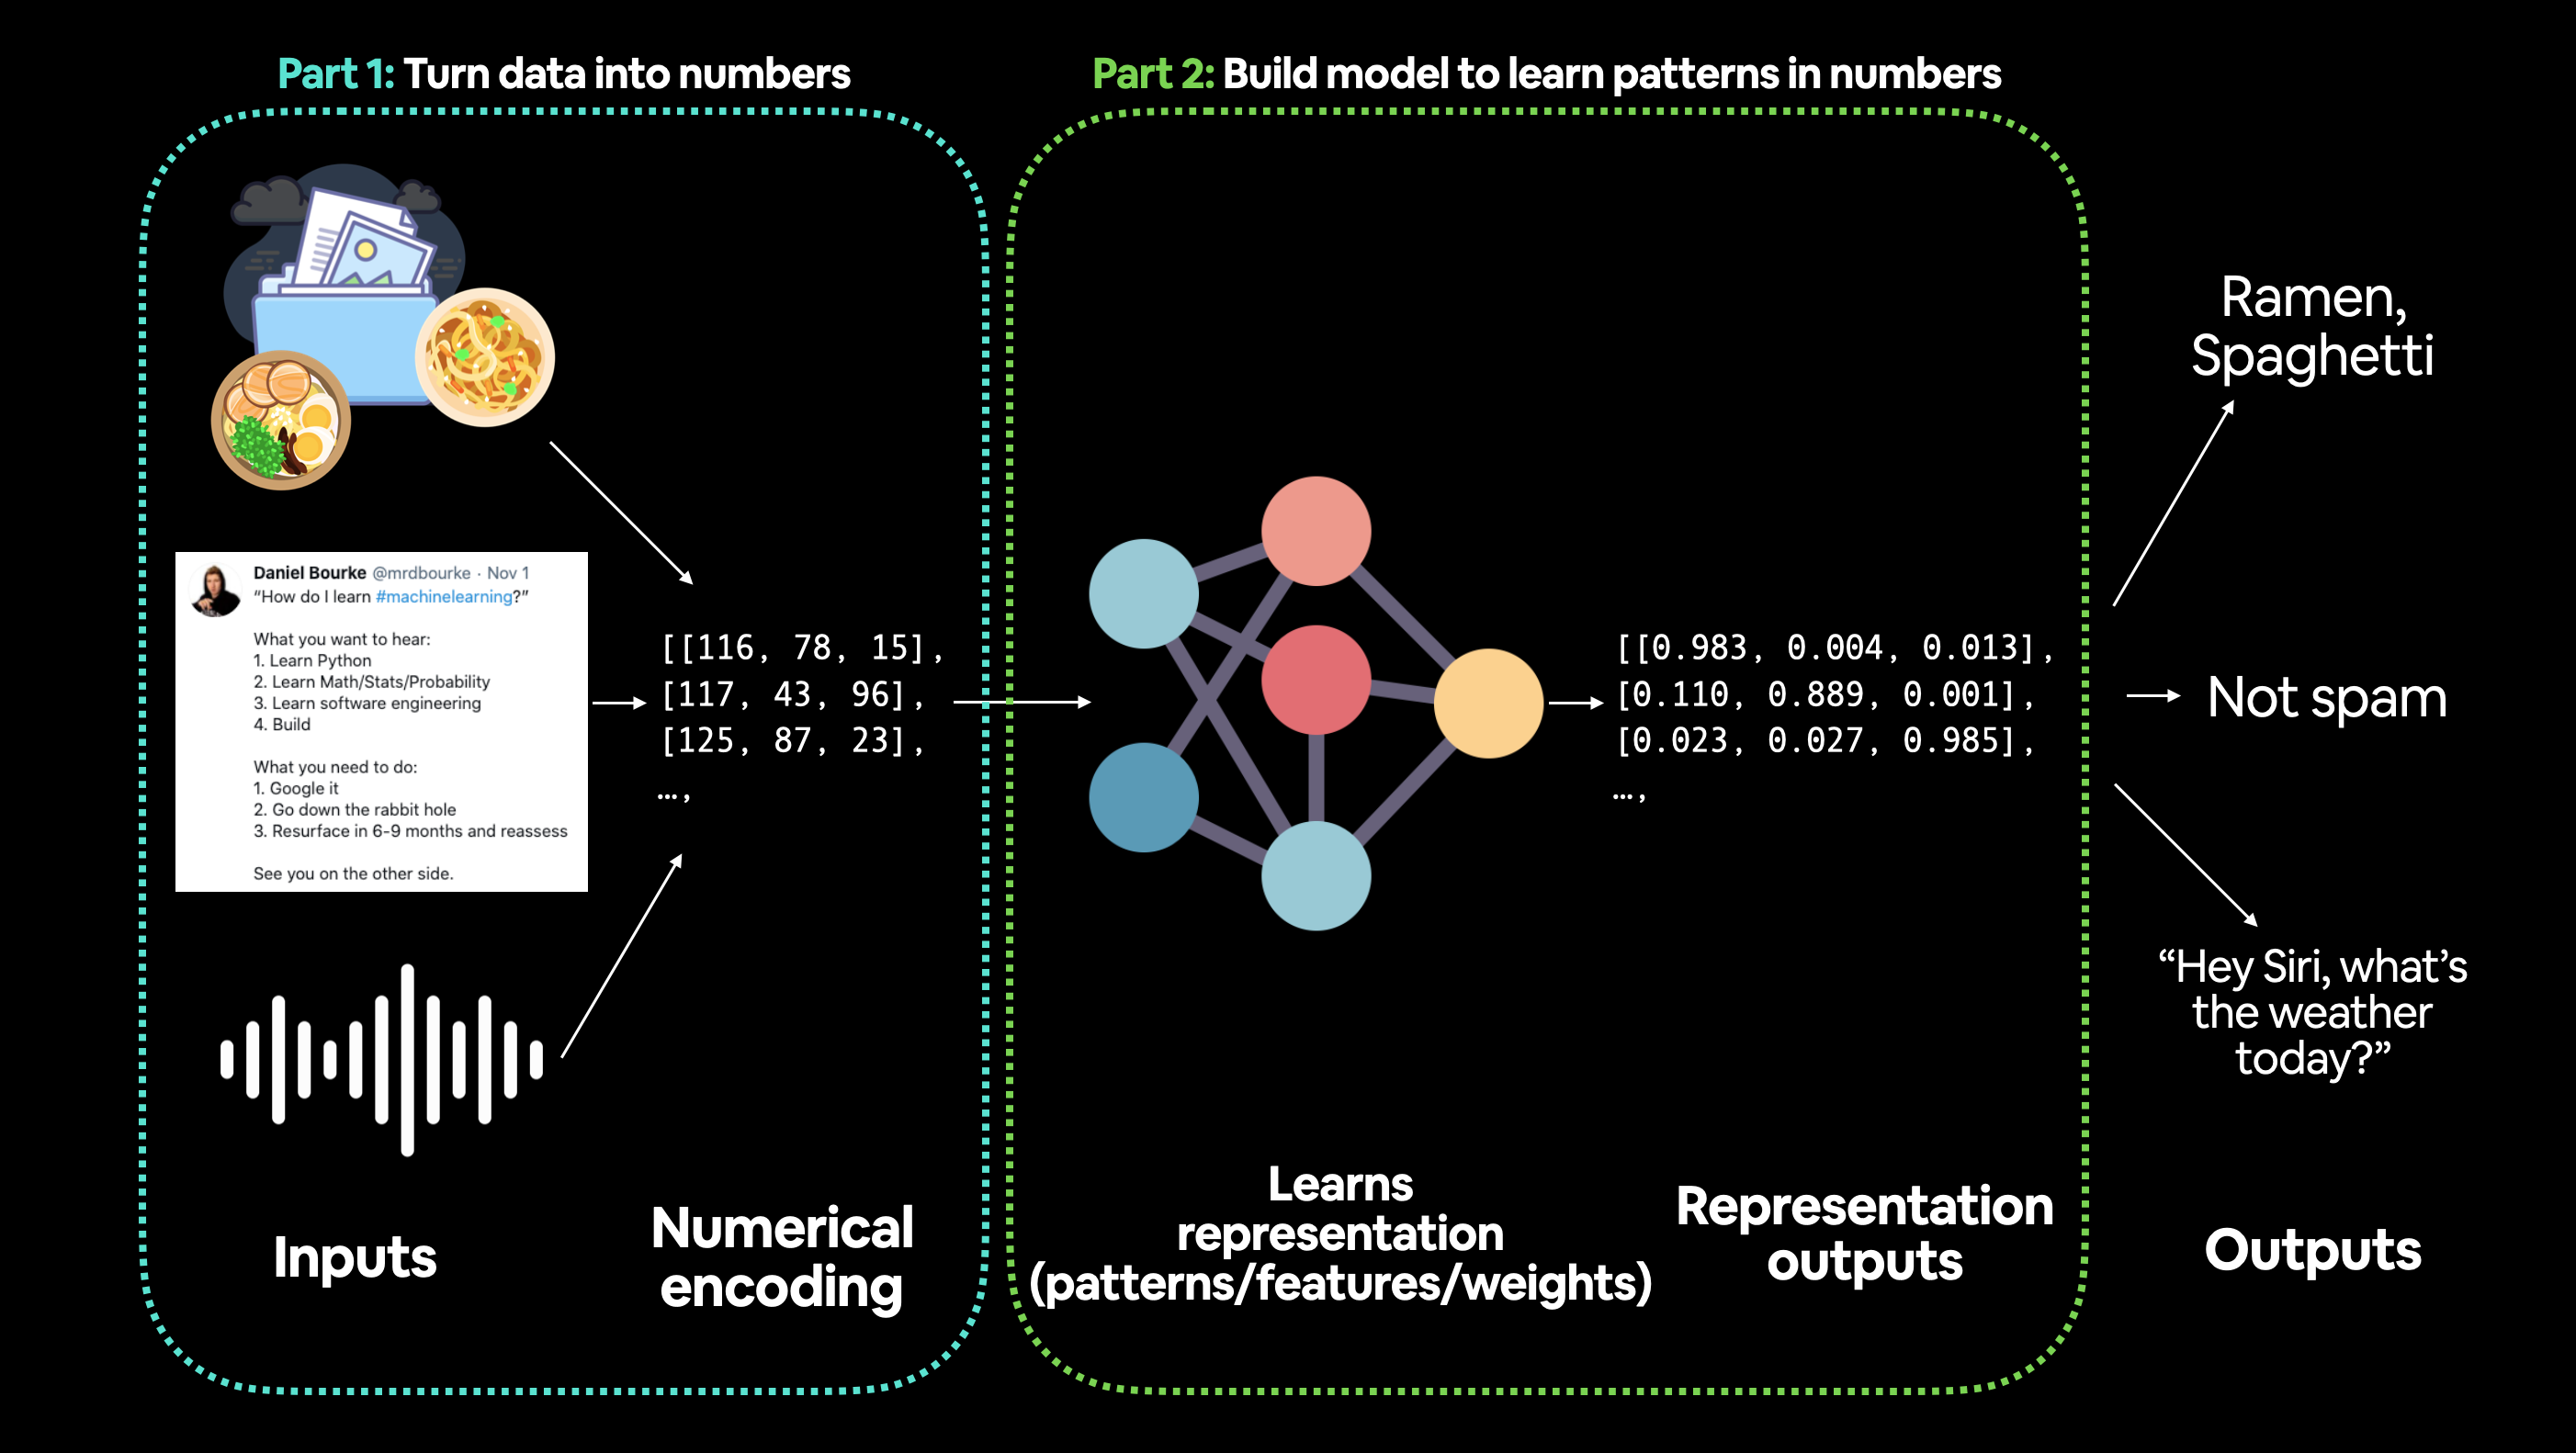

we'll use a linear regression formula to make a straight line with known **parameters**

In [ ]:
# create *Known* parameters

weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in ML in general)

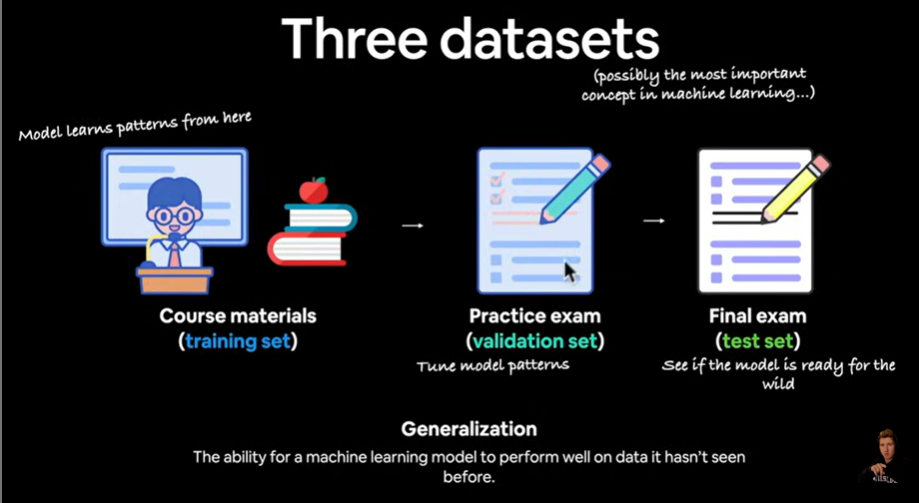

In [ ]:
# create a train/test split
train_split = int(0.80 * len(X))
train_split

40

In [ ]:
test_split = int(0.20 * len(y))
test_split

10

In [ ]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

How might we better visualize our data?
This is where the data explorer's motto comes in!

In [ ]:
def plot_predictions(train_data=X_train, train_labels=y_train,test_data=X_test, test_labels= y_test, predictions=None):
  """
  plots training data, test data and comapares predictions.
  """
  plt.figure(figsize=(10,7))

  # Plot training data in Red
  plt.scatter(train_data, train_labels, c="r", s=4, label="Training data")

  # Plot test data in blue
  plt.scatter(test_data, test_labels, c="b", s=4, label="Test data")

  # Are there predictions?
  if predictions is not None:
    #plot predictions if they exist
    plt.scatter(test_data, predictions, c="g", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

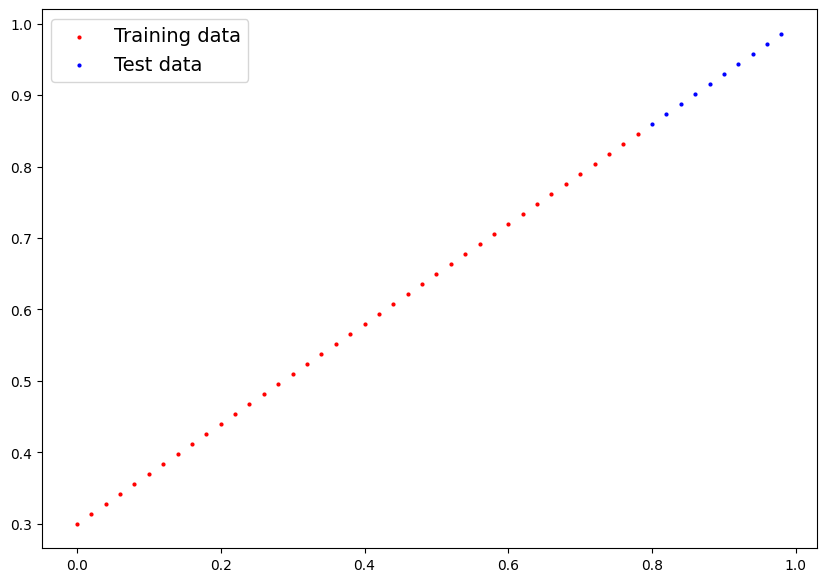

In [ ]:
plot_predictions();

**torch.rand()** -> generates random number that follow Uniform Distribution.
*Properties:*
- Range: 0 ≤ x < 1
- Mean ≈ 0.5
- No negative values
- Flat probability density


**torch.randn()** -> generates random numbers that follow Normal (Gaussian) distribution.
*Properties:*
- Mean ≈ 0
- Std dev ≈ 1
- Can be negative or positive
- Bell-shaped distribution

## 2. Building Pytorch model

What our model does:
* start with random values (weights & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?
Through two main algorithms:
1. Gradient descent

- Gradient Descent itself does NOT calculate gradients.
It uses gradients.
 - Gradient calculation → done by backpropagation + autograd
- Gradient descent → optimization rule that updates weights using gradients.

Gradient descent is why we have 'requires_grad = True' as default.

torch.autograd -> implements gradient descent in PyTorch

Gradient Descent uses the gradients (derivatives) computed by backpropagation to update model parameters in the direction that minimizes the loss.
* Purpose: parameter update

2. Backpropagation
Backpropagation computes the gradient of the loss function with respect to each model parameter by applying the chain rule from output layer back to input layers.

This is why parameters have requires_grad = True

 - Gradients are stored in param.grad
- Purpose: gradient computation


We update parameters.
Then we simply run a new forward pass with updated weights.


Loop:
Forward pass → compute loss
Backpropagation → compute gradients
Gradient descent → update weights
Repeat....



One-line distinction (very important):
 - Backpropagation computes gradients.
 - Gradient descent uses gradients.


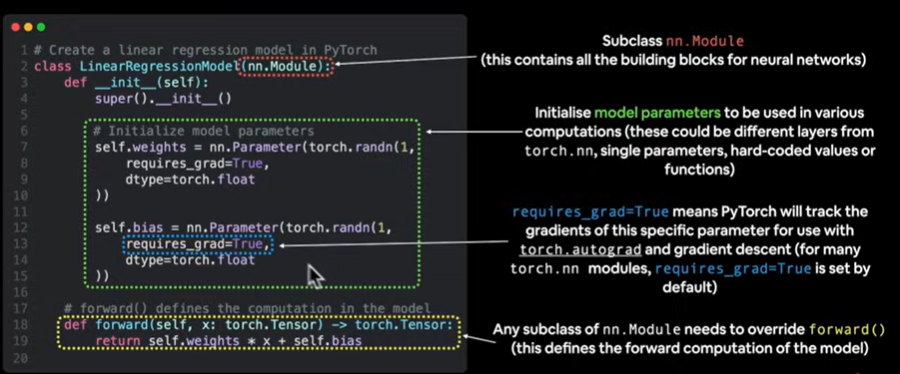

In [ ]:
import torch
from torch import nn
# Create a linear regression model class

class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()

    # initialize model parameters
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    # nn.Parameter is a type of tensor that is considered a module parameter. Parameters are torch.Tensor subclasses that have a very special
    # property when used with Module (nn.Module)
    self.bias = nn.Parameter(torch.rand(1, requires_grad=True, dtype=torch.float))


    # Forward pass method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # <- x is the input data
    return self.weights * x + self.bias # this is the linear regression model


# PyTorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph)

* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us

* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()

* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent.
Optimizers optimize the model parameters so as to better represent our data

* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

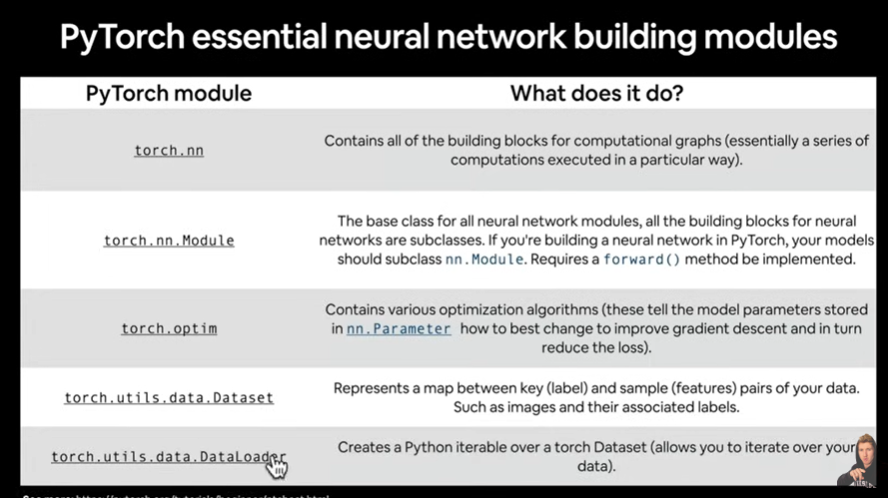

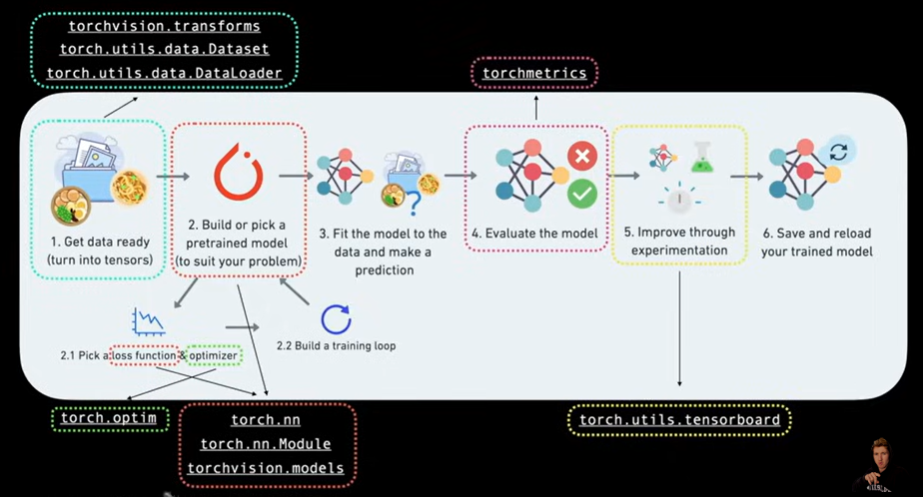

### Checking the contents of our PyTorch model

we can check our model parameters or what's inside our model using `.parameters()`


In [ ]:
torch.manual_seed(42)
torch.randn(1)

tensor([0.3367])

In [ ]:
torch.randn(2,3)

tensor([[ 0.1288,  0.2345,  0.2303],
        [-1.1229, -0.1863,  2.2082]])

In [ ]:
# create a random seed
torch.manual_seed(42)   # -> for reproducibility

# Create an instance of the model (this is a subclass of nn.Module)

model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

In [ ]:
print(model_0)
print(hasattr(model_0, "forward"))

LinearRegressionModel()
True


In [ ]:
print(id(model_0))
print(model_0.__class__)
print(model_0.forward)

134657478599664
<class '__main__.LinearRegressionModel'>
<bound method LinearRegressionModel.forward of LinearRegressionModel()>


### Making predictions using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`
When we pass data through our model, it's going to run it through the forward() method.

In [ ]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [ ]:
print(id(model_0))
print(model_0.__class__)
print(model_0.forward)

134657478599664
<class '__main__.LinearRegressionModel'>
<bound method LinearRegressionModel.forward of LinearRegressionModel()>


In [ ]:
# Make predictions with model

with torch.inference_mode(): # disables requires_grad, turns off gradient tracking, because we are doing inference here and not training so we don't need to keep track of gradients
  y_preds = model_0(X_test)  # with inference_mode -> predictions are a lot faster, because PyTorch is now keeping track of lesser data, so memory saved and faster predictions

# # we can also do something similar with torch.no_grad(), however torch.inference_mode() is preferred
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds

tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]])

In [ ]:
y_preds1 = model_0(X_test)
print(y_preds1)

tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]], grad_fn=<AddBackward0>)


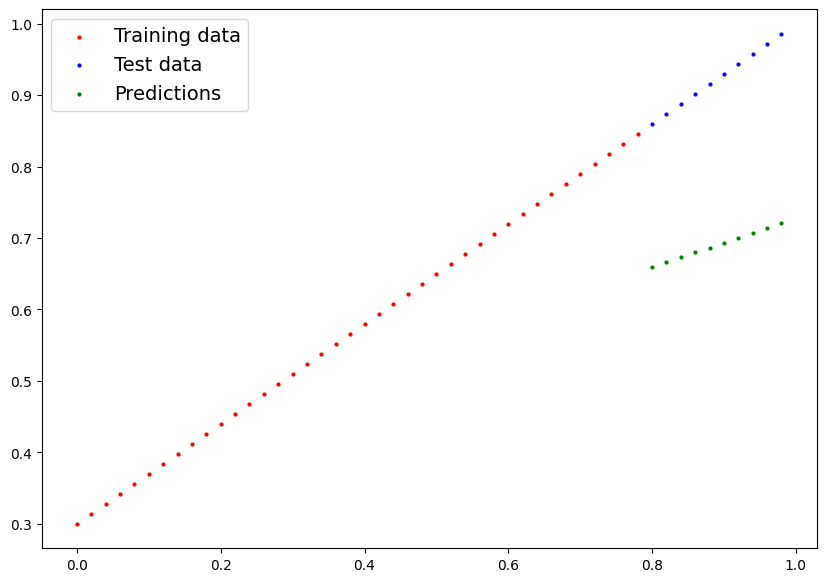

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
errors = y_preds - y_test

print(errors)
print(len(errors))

tensor([[-0.2002],
        [-0.2075],
        [-0.2147],
        [-0.2220],
        [-0.2293],
        [-0.2365],
        [-0.2438],
        [-0.2511],
        [-0.2583],
        [-0.2656]])
10


In [ ]:
# another way to compute error = y_pred - y_test

errors = []

for y_pred, y_true in zip(y_preds, y_test):
    e = y_pred - y_true
    errors.append(e)

print(errors)
print(len(errors))

[tensor([-0.2002]), tensor([-0.2075]), tensor([-0.2147]), tensor([-0.2220]), tensor([-0.2293]), tensor([-0.2365]), tensor([-0.2438]), tensor([-0.2511]), tensor([-0.2583]), tensor([-0.2656])]
10


## 3. Train models

The whole idea of training is for a model to move from some **unknown** parameters (these may be random) to some known parameters
Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models are is to use Loss function


Note: Loss function also called Cost function, Criterion

Things we need to train:

**Loss function**: A function to measure how wrong your model's prediction are to the ideal outputs. lower is better.

**Optimizer** : Takes into account the loss of a model and adjusts the model's parameters (e.g weights and bias) in our case, to improve the loss funtion (reduce the loss)
- inside the optimizer, we'll have to set two parameters:
- params - the model parameters you'd like to optimize, for example `params=model_0.parameters()`
- lr = learning rate -> the learning rate is a hyperparameter that defines how big/small the ptimizer changes the parameters with each step (smaller lr -> small changes in model parameters, bigger lr -> large changes in model parameters)





And specifically for PyTorch, we need:

* A training loop
* A testing loop



In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.3904], requires_grad=True)]

In [ ]:
# check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

* L1 loss is MAE = Mean Absolute Error
* L2 Loss is MSE = Mean Squared error



In [ ]:
# Setup a loss function
loss_fn = nn.L1Loss()
loss_fn

L1Loss()

In [ ]:
# setting up optimizer torch.optim -> see algorithms, Adam, RMSprop, SGD

# setting SGD optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # lr = learning rate = possibly the most important hyperparameter you can set


# smaller the learning rate -> smaller the change in the parameter
# larger the learning rate -> larger the change in the parameter